In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px



url = "https://docs.google.com/spreadsheets/d/1OmnQ7Yut5YDj-7n4LpLtceW8NGWWp3UW/export?format=csv"

df = pd.read_csv(url)

df.head(10)

,Iso3_code,Country,Region,Subregion,Indicator,Dimension,Category,Sex,Age,Year,Unit of measurement,VALUE,Source
0,ARM,Armenia,Asia,Western Asia,Persons arrested/suspected for intentional hom...,by citizenship,National citizens,Male,Total,2013,Counts,35,CTS
1,CHE,Switzerland,Europe,Western Europe,Persons arrested/suspected for intentional hom...,by citizenship,National citizens,Male,Total,2013,Counts,28,CTS
2,COL,Colombia,Americas,Latin America and the Caribbean,Persons arrested/suspected for intentional hom...,by citizenship,National citizens,Male,Total,2013,Counts,15053,CTS
3,CZE,Czechia,Europe,Eastern Europe,Persons arrested/suspected for intentional hom...,by citizenship,National citizens,Male,Total,2013,Counts,69,CTS
4,DEU,Germany,Europe,Western Europe,Persons arrested/suspected for intentional hom...,by citizenship,National citizens,Male,Total,2013,Counts,455,CTS
5,FIN,Finland,Europe,Northern Europe,Persons arrested/suspected for intentional hom...,by citizenship,National citizens,Male,Total,2013,Counts,70,CTS
6,GTM,Guatemala,Americas,Latin America and the Caribbean,Persons arrested/suspected for intentional hom...,by citizenship,National citizens,Male,Total,2013,Counts,2764,CTS
7,HND,Honduras,Americas,Latin America and the Caribbean,Persons arrested/suspected for intentional hom...,by citizenship,National citizens,Male,Total,2013,Counts,905,CTS
8,HUN,Hungary,Europe,Eastern Europe,Persons arrested/suspected for intentional hom...,by citizenship,National citizens,Male,Total,2013,Counts,229,CTS
9,ISL,Iceland,Europe,Northern Europe,Persons arrested/suspected for intentional hom...,by citizenship,National citizens,Male,Total,2013,Counts,1,CTS


# Features:

In [ ]:
regioes = df['Region'].unique()
print('Regioes: ', regioes)

Regioes:  ['Asia' 'Europe' 'Americas' 'Africa' 'Oceania' 'World'
 'Australia and New Zealand' 'Central Asia' 'Eastern Asia'
 'Eastern Europe' 'Latin America and the Caribbean' 'Melanesia'
 'Micronesia' 'Northern Africa' 'Northern America' 'Northern Europe'
 'Polynesia' 'South-eastern Asia' 'Southern Asia' 'Southern Europe'
 'Sub-Saharan Africa' 'Western Asia' 'Western Europe']


In [ ]:
subregioes = df['Subregion'].unique()
print('Subregioes: ', subregioes)

Subregioes:  ['Western Asia' 'Western Europe' 'Latin America and the Caribbean'
 'Eastern Europe' 'Northern Europe' 'Southern Europe' 'Eastern Asia'
 'Southern Asia' 'Central Asia' 'Northern America' 'Northern Africa'
 'Sub-Saharan Africa' 'Australia and New Zealand' 'Melanesia'
 'South-eastern Asia' 'Micronesia' 'Polynesia' 'Africa' 'Americas' 'Asia'
 'Europe' 'Oceania' 'World']


In [ ]:
indicadores = df['Indicator'].unique()
print('Indicadores: ', indicadores)

Indicadores:  ['Persons arrested/suspected for intentional homicide'
 'Victims of intentional homicide'
 'Victims of intentional homicide – City-level data'
 'Persons convicted for intentional homicide'
 'Death due to intentional homicide in prison'
 'Victims of Intentional Homicide - Regional Estimate']


In [ ]:
dimensoes = df['Dimension'].unique()
print('Dimensoes: ', dimensoes)

Dimensoes:  ['by citizenship' 'Total' 'by relationship to perpetrator'
 'by situational context' 'by mechanisms' 'by location']


In [ ]:
categorias = df['Category'].unique()
print('Categorias: ', categorias)

Categorias:  ['National citizens' 'Foreign citizens' 'Total'
 'Intimate partner or family member'
 'Intimate partner or family member: Intimate partner'
 'Intimate partner or family member: Family member'
 'Other Perpetrator known to the victim'
 'Perpetrator unknown to the victim'
 'Perpetrator to victim relationship unknown'
 'Organized criminal groups or gangs' 'Other criminal activities'
 'Interpersonal homicide' 'Socio-political homicide'
 'Socio-political homicide - terrorist offences'
 'Unknown types of homicide' 'Firearms or explosives'
 'Firearms or explosives - firearms' 'Another weapon'
 'Another weapon - sharp object' 'Without a weapon/ other Mechanism'
 'Unspecified means' '2nd largest city' '3rd largest city'
 '1st largest city']


In [ ]:
sexos = df['Sex'].unique()
print('Sexos: ', sexos)

Sexos:  ['Male' 'Female' 'Total']


In [ ]:
idades = df['Age'].unique()
print('Idades: ', idades)

Idades:  ['Total' 'Unknown' '0-9' '10 -14' '15 -17' '18-19' '20-24' '25-29' '30-44'
 '45-59' '60 and older']


In [ ]:
medidas = df['Unit of measurement'].unique()
print('Medidas: ', medidas)

Medidas:  ['Counts' 'Rate per 100,000 population']


# Tratamento:

In [ ]:
# Tratando os valores para virarem numéricos
df['VALUE'] = df['VALUE'].astype(str).str.replace(',', '.')
df['VALUE'] = pd.to_numeric(df['VALUE'], errors='coerce')

# Perguntas


## Quais países apresentam os 10 maiores índices de homicídios nos últimos 5 anos?

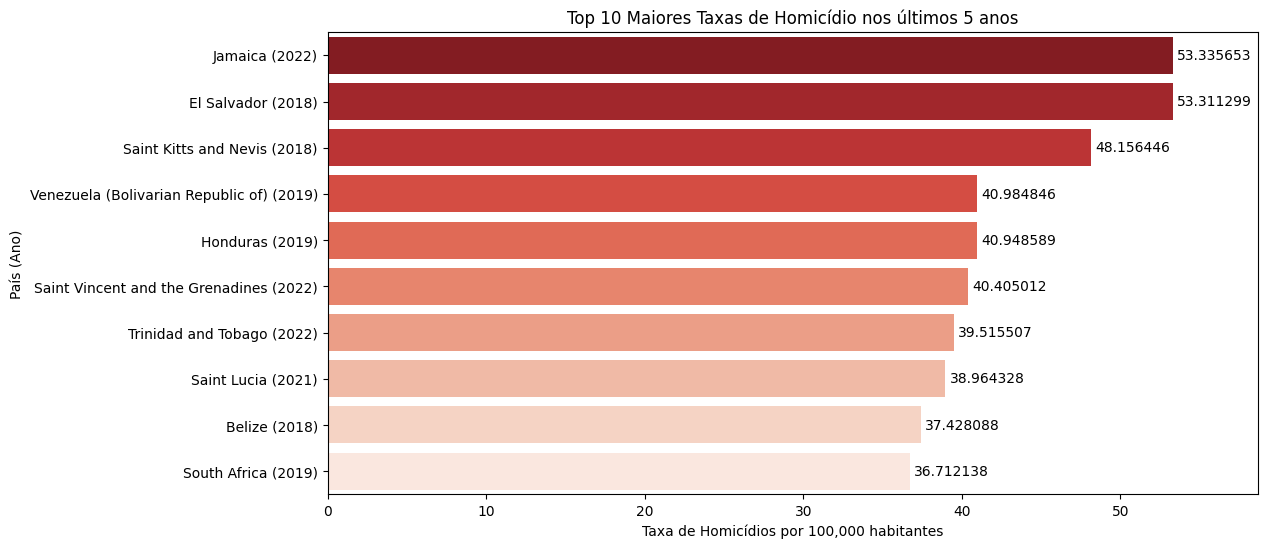

In [154]:
latest_year = df['Year'].max()

filtro = (
    (df['Year'] > (latest_year-5)) &
    (df['Indicator'] == 'Victims of intentional homicide') &
    (df['Dimension'] == 'Total') &
    (df['Category'] == 'Total') &
    (df['Sex'] == 'Total') &
    (df['Age'] == 'Total') &
    (df['Unit of measurement'] == 'Rate per 100,000 population')
)

df1 = df[filtro]

indices = df1.groupby(['Country'])['VALUE'].idxmax()

top10 = df1.loc[indices, ['Iso3_code', 'Country', 'Year', 'VALUE']].sort_values(by='VALUE', ascending=False).head(10)
top10['Pais_Ano'] = top10['Country'] + ' (' + top10['Year'].astype(str) + ')'

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=top10,
    x='VALUE',
    y='Pais_Ano',
    hue='Pais_Ano',
    palette='Reds_r'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.6f', padding=3)

plt.xlabel('Taxa de Homicídios por 100,000 habitantes')
plt.ylabel('País (Ano)')
plt.title('Top 10 Maiores Taxas de Homicídio nos últimos 5 anos')

plt.xlim(0, top10['VALUE'].max() * 1.1)

plt.show()

In [155]:
fig = px.choropleth(
    df1,
    locations="Iso3_code",
    locationmode="ISO-3",
    color="VALUE",
    hover_name="Country",
    color_continuous_scale="Reds",
    projection="natural earth",
    title="Taxa de Homicídios por 100.000 habitantes",
    labels={'VALUE': 'Taxa'}
)

fig.show()

## Quais países apresentam os 10 maiores índices de homicídios de mulheres em 2022?

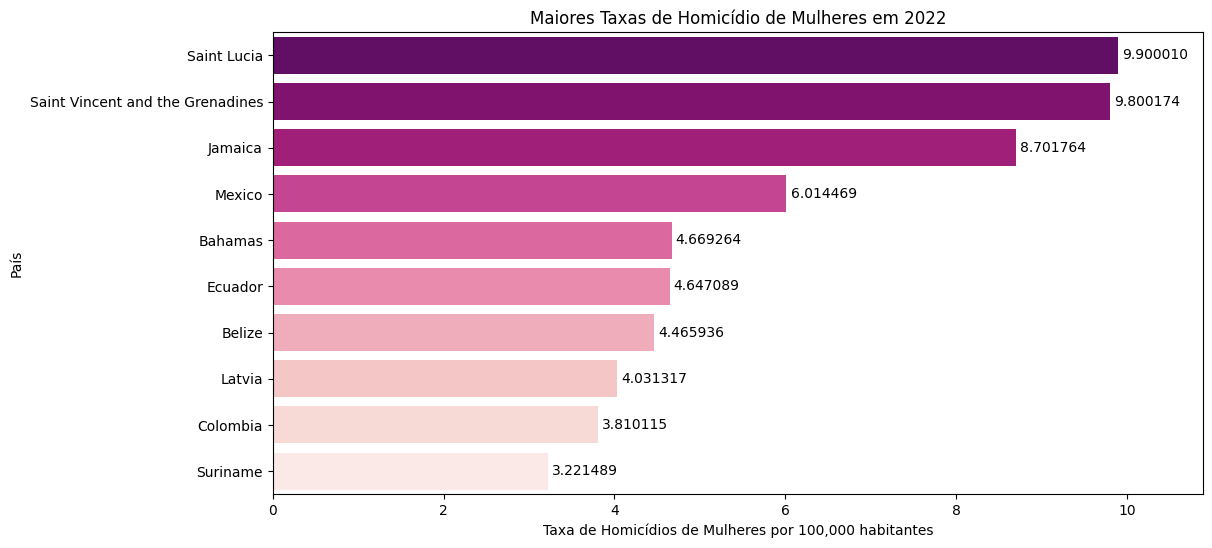

In [ ]:
filtro = (
    (df['Year'] == 2022) &
    (df['Indicator'] == 'Victims of intentional homicide') &
    (df['Dimension'] == 'Total') &
    (df['Category'] == 'Total') &
    (df['Sex'] == 'Female') &
    (df['Age'] == 'Total') &
    (df['Unit of measurement'] == 'Rate per 100,000 population')
)

df2 = df[filtro]

indices = df2.groupby(['Country'])['VALUE'].idxmax()

top10 = df2.loc[indices, ['Iso3_code', 'Country', 'VALUE']].sort_values(by='VALUE', ascending=False).head(10)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=top10,
    x='VALUE',
    y='Country',
    hue='Country',
    palette='RdPu_r'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.6f', padding=3)

plt.xlabel('Taxa de Homicídios de Mulheres por 100,000 habitantes')
plt.ylabel('País')
plt.title('Maiores Taxas de Homicídio de Mulheres em 2022')

plt.xlim(0, top10['VALUE'].max() * 1.1)

plt.show()

## Quais as regiões com mais homicídios?

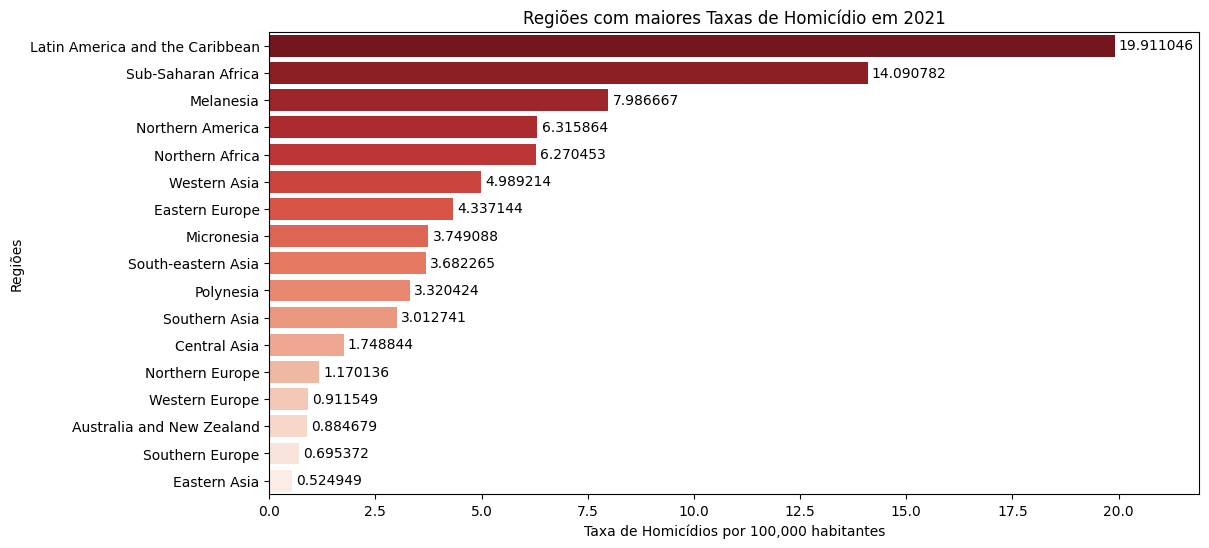

In [ ]:
todos = ['All Africa', 'All Europe', 'All Americas', 'All Asia', 'All Oceania', 'World']

year = 2021

filtro = (
    (df['Year'] == year) &
    (df['Indicator'] == 'Victims of Intentional Homicide - Regional Estimate') &
    (df['Dimension'] == 'Total') &
    (df['Category'] == 'Total') &
    (df['Sex'] == 'Total') &
    (df['Age'] == 'Total') &
    (df['Unit of measurement'] == 'Rate per 100,000 population') &
    (~df['Country'].astype(str).isin(todos))
)

df3 = df[filtro].sort_values(by='VALUE', ascending=False)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=df3,
    x='VALUE',
    y='Region',
    hue='Region',
    palette='Reds_r'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.6f', padding=3)

plt.xlabel('Taxa de Homicídios por 100,000 habitantes')
plt.ylabel('Regiões')
plt.title(f'Regiões com maiores Taxas de Homicídio em {year}')

plt.xlim(0, df3['VALUE'].max() * 1.1)

plt.show()



## Quais países com menor número de homicídios em cada subregião?

In [ ]:
#print(regioes)

continentes = regioes[0:5]

#print(continentes)

filtro = (
    (df['Year'] >= 2019) & # Porque 2019? Ano mais recente no qual todas as subregiões possuem dados para escolher um país! A partir de 2020, Micronesia e Polynesia não possuem dados.
    (df['Indicator'] == 'Victims of intentional homicide') &
    (df['Dimension'] == 'Total') &
    (df['Category'] == 'Total') &
    (df['Sex'] == 'Total') &
    (df['Age'] == 'Total') &
    (df['Unit of measurement'] == 'Counts')
)

paises = pd.DataFrame()

for subregiao in subregioes:
  df4 = df[filtro & (df['Subregion'] == subregiao)].sort_values(by='VALUE', ascending=True)
  if not df4.empty:
      primeira_linha = df4.iloc[[0]]
      paises = pd.concat([paises, primeira_linha], ignore_index=True)
  else:
      print(f"Sem dados para: {subregiao}")

paises[['Subregion','Country','Year','VALUE']].head(20)




Sem dados para: Africa
Sem dados para: Americas
Sem dados para: Asia
Sem dados para: Europe
Sem dados para: Oceania
Sem dados para: World


,Subregion,Country,Year,VALUE
0,Western Asia,Bahrain,2020,0.0
1,Western Europe,Liechtenstein,2019,1.0
2,Latin America and the Caribbean,Cayman Islands,2019,2.0
3,Eastern Europe,Slovakia,2022,42.0
4,Northern Europe,Iceland,2019,1.0
5,Southern Europe,Holy See,2019,0.0
6,Eastern Asia,"China, Macao Special Administrative Region",2019,2.0
7,Southern Asia,Maldives,2019,3.0
8,Central Asia,Tajikistan,2020,87.0
9,Northern America,Bermuda,2019,0.0


## Quais países com menor número de morte de mulheres?


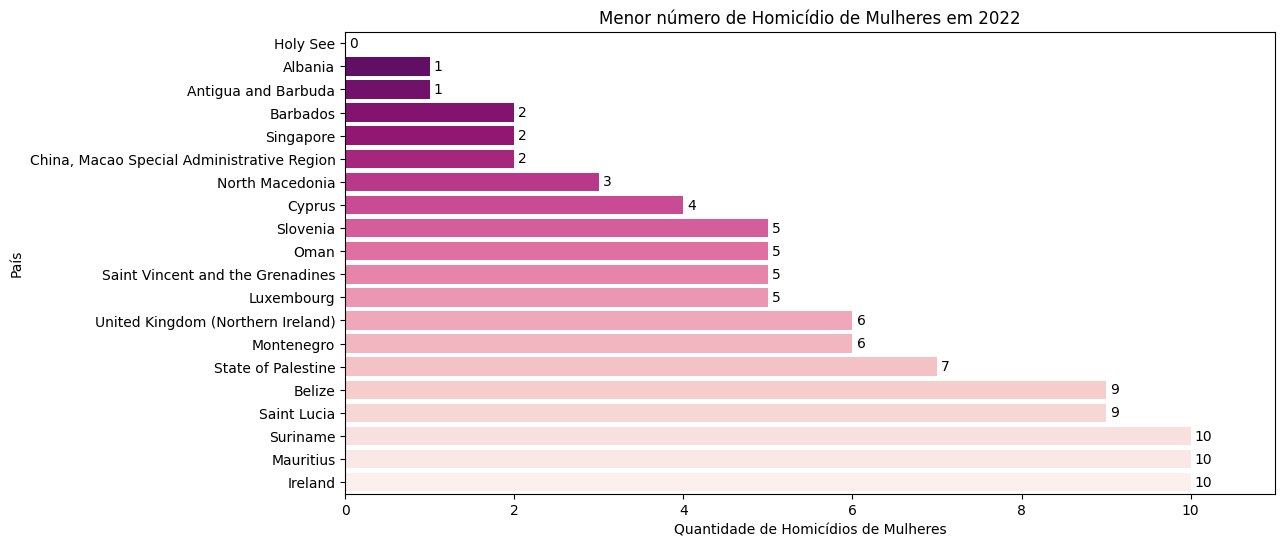

In [ ]:
year = 2022 # 2022 ano mais recente com dados

filtro = (
    (df['Year'] == year) &
    (df['Indicator'] == 'Victims of intentional homicide') &
    (df['Dimension'] == 'Total') &
    (df['Category'] == 'Total') &
    (df['Sex'] == 'Female') &
    (df['Age'] == 'Total') &
    (df['Unit of measurement'] == 'Counts')
)

df5 = df[filtro]

top10 = df5.sort_values(by='VALUE', ascending=True).head(20)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=top10,
    x='VALUE',
    y='Country',
    hue='Country',
    palette='RdPu_r'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.xlabel('Quantidade de Homicídios de Mulheres')
plt.ylabel('País')
plt.title(f'Menor número de Homicídio de Mulheres em {year}')

plt.xlim(0, top10['VALUE'].max() * 1.1)

plt.show()

## Quais as subregiões com maior número de homicídios?


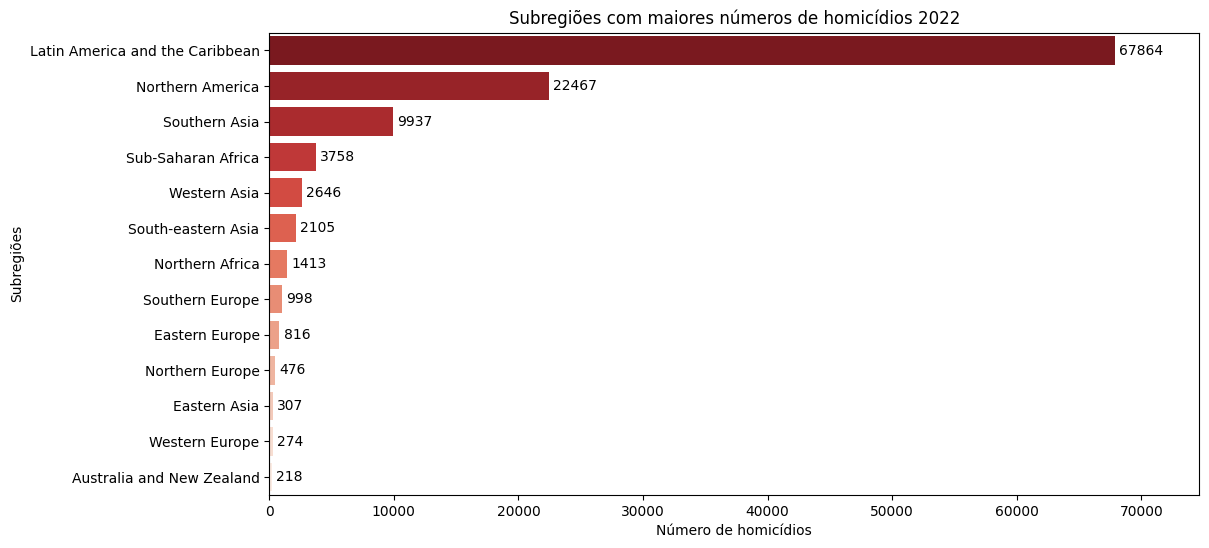

In [ ]:
year = 2022

filtro = (
    (df['Year'] == year) &
    (df['Indicator'] == 'Victims of intentional homicide') &
    (df['Dimension'] == 'Total') &
    (df['Category'] == 'Total') &
    (df['Sex'] == 'Total') &
    (df['Age'] == 'Total') &
    (df['Unit of measurement'] == 'Counts')
)

df6 = df[filtro]

ranking = df6.groupby(['Subregion'])['VALUE'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=ranking,
    x='VALUE',
    y='Subregion',
    hue='Subregion',
    palette='Reds_r'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.xlabel('Número de homicídios')
plt.ylabel('Subregiões')
plt.title(f'Subregiões com maiores números de homicídios {year}')

plt.xlim(0, ranking['VALUE'].max() * 1.1)

plt.show()

## Identifique o país com maior número de homicídios em cada continente em 2020


In [ ]:
#print(regioes)

continentes = regioes[0:5]

#print(continentes)

year = 2020

filtro = (
    (df['Year'] == year) &
    (df['Indicator'] == 'Victims of intentional homicide') &
    (df['Dimension'] == 'Total') &
    (df['Category'] == 'Total') &
    (df['Sex'] == 'Total') &
    (df['Age'] == 'Total') &
    (df['Unit of measurement'] == 'Counts')
)

paises = pd.DataFrame()

for continente in continentes:
  df1 = df[filtro & (df['Region'] == continente)].sort_values(by='VALUE', ascending=False)
  primeira_linha = df1.iloc[[0]]
  paises = pd.concat([paises, primeira_linha], ignore_index=True)

paises.head(5)



,Iso3_code,Country,Region,Subregion,Indicator,Dimension,Category,Sex,Age,Year,Unit of measurement,VALUE,Source
0,IND,India,Asia,Southern Asia,Victims of intentional homicide,Total,Total,Total,Total,2020,Counts,40651.0,MoI/NCRB India
1,RUS,Russian Federation,Europe,Eastern Europe,Victims of intentional homicide,Total,Total,Total,Total,2020,Counts,10697.0,NSO/GSH 2019 Revision/CTS/GSH 2023 Revision
2,BRA,Brazil,Americas,Latin America and the Caribbean,Victims of intentional homicide,Total,Total,Total,Total,2020,Counts,47722.0,MD Adjusted/DATASUS
3,ZAF,South Africa,Africa,Sub-Saharan Africa,Victims of intentional homicide,Total,Total,Total,Total,2020,Counts,19972.0,NP/CTS
4,AUS,Australia,Oceania,Australia and New Zealand,Victims of intentional homicide,Total,Total,Total,Total,2020,Counts,221.0,MD/Eurostat/GSH 2019 Revision/CTS


## Qual o país mais violento para as mulheres em 2021?


In [ ]:
filtro = (
    (df['Year'] == 2021) &
    (df['Indicator'] == 'Victims of intentional homicide') &
    (df['Dimension'] == 'Total') &
    (df['Category'] == 'Total') &
    (df['Sex'] == 'Female') &
    (df['Age'] == 'Total') &
    (df['Unit of measurement'] == 'Rate per 100,000 population')
)

df1 = df[filtro]

df1.groupby(['Country'])['VALUE'].max().sort_values(ascending=False).head(10)

,VALUE
Country,
Antigua and Barbuda,10.265149
Jamaica,9.335017
Saint Lucia,8.819168
Botswana,7.629581
Myanmar,7.288432
Namibia,6.799161
Honduras,6.466649
Mexico,6.171259
Guatemala,6.129440


## Qual o país com maior valor de 'indicador: Victims of intentional homicide'?


In [ ]:
filtro = (
    (df['Indicator'] == 'Victims of intentional homicide') &
    (df['Dimension'] == 'Total') &
    (df['Category'] == 'Total') &
    (df['Sex'] == 'Total') &
    (df['Age'] == 'Total') &
    (df['Unit of measurement'] == 'Counts')
)

df1 = df[filtro]

df1.groupby(['Country'])['VALUE'].max().sort_values(ascending=False).head(1)

,VALUE
Country,
Brazil,63788.0


## Qual a média de homicídios no Brasil nos últimos 10 anos?

In [ ]:
filtro = (
    (df['Country'] == 'Brazil') &
    (df['Indicator'] == 'Victims of intentional homicide') &
    (df['Unit of measurement'] == 'Counts') &
    (df['Dimension'] == 'Total') &
    (df['Category'] == 'Total') &
    (df['Sex'] == 'Total') &
    (df['Age'] == 'Total')
)

latest_year = df[filtro]['Year'].max()

valores = []

for i in range(10):
  year = latest_year - i
  valores.append(df[filtro & (df['Year'] == year)]['VALUE'].sum())

print(valores)

array_numerico = np.array(valores, dtype=int)
media = np.mean(array_numerico)

print("Media:", media)

[np.float64(45562.0), np.float64(47722.0), np.float64(44073.0), np.float64(55980.0), np.float64(63788.0), np.float64(61208.0), np.float64(58184.0), np.float64(59733.0), np.float64(56845.0), np.float64(56388.0)]
Media: 54948.3


# Definir estratégia de regressão para predizer taxa de homicídios nos anos seguintes: 2023, 2024, 2025 e 2026.

##Utilizaremos uma regressão linear para a previsão da taxa de homicídios nos anos seguintes. Entretanto, isso exige assumir que a evolução das taxas de homicídio ao longo do tempo segue um comportamento aproximadamente linear, hipótese que nem sempre será válida para todos os países. Além disso, há o problema de o conjunto de dados disponível ser relativamente pequeno: para cada país, temos apenas observações entre 2012 e 2022, totalizando cerca de 11 pontos de dados. Essa quantidade limitada pode comprometer a capacidade de generalização do modelo e resultar em previsões com erro elevado.

##Vamos primeiramente analisar o coeficiente de Pearson:
$$r = \frac{cov(X,Y)}{\sigma_X \sigma_Y}$$

##E através da função describe() entendermos melhor como essa relação entre variável dependente e independente se comporta





In [ ]:
df['VALUE'] = (
    df['VALUE']
    .astype(str)
    .str.replace(',', '.', regex=False)
)

df['VALUE'] = pd.to_numeric(df['VALUE'], errors='coerce')

filtro = (
    (df['Year'] >= 2012) &
    (df['Year'] <= 2022) &
    (df['Indicator'] == 'Victims of intentional homicide') &
    (df['Dimension'] == 'Total') &
    (df['Category'] == 'Total') &
    (df['Sex'] == 'Total') &
    (df['Age'] == 'Total') &
    (df['Unit of measurement'] == 'Rate per 100,000 population')
)

df1 = df[filtro].copy()

df1 = df1.dropna(subset=['VALUE'])

resultados = []

for pais in df1['Country'].unique():

    dados_pais = df1[df1['Country'] == pais].sort_values('Year')

    if len(dados_pais) < 2:
        continue

    correlacao = dados_pais['Year'].corr(
        dados_pais['VALUE'],
        method='pearson'
    )

    resultados.append({
        'Country': pais,
        'Pearson': correlacao
    })

tabela_correlacao = pd.DataFrame(resultados)

tabela_correlacao = tabela_correlacao.sort_values(
    by='Pearson',
    ascending=False
)

tabela_correlacao['Pearson'].describe()

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning:

invalid value encountered in divide

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning:

invalid value encountered in divide



,Pearson
count,166.000000
mean,-0.253271
std,0.650368
min,-1.000000
25%,-0.808224
50%,-0.488222
75%,0.340461
max,1.000000


## Podemos observar que em média os países **não** apresentam uma tendência linear forte entre ano e taxa de homicídio.
## E com o desvio padrão de **0.65**, podemos observar uma grande variabilidade em relação ao coeficiente de Pearson entre os países.

In [ ]:
from sklearn.linear_model import LinearRegression

df['VALUE'] = (
    df['VALUE']
    .astype(str)
    .str.replace(',', '.', regex=False)
)

df['VALUE'] = pd.to_numeric(df['VALUE'], errors='coerce')

filtro = (
    (df['Year'] >= 2012) &
    (df['Year'] <= 2022) &
    (df['Indicator'] == 'Victims of intentional homicide') &
    (df['Dimension'] == 'Total') &
    (df['Category'] == 'Total') &
    (df['Sex'] == 'Total') &
    (df['Age'] == 'Total') &
    (df['Unit of measurement'] == 'Rate per 100,000 population')
)

df1 = df[filtro].copy()

df1 = df1.dropna(subset=['VALUE'])

resultados = []

for pais in df1['Country'].unique():

    dados_pais = df1[df1['Country'] == pais].sort_values('Year')

    if len(dados_pais) < 2:
        continue

    X = (dados_pais['Year'] - 2012).values.reshape(-1, 1)

    y = dados_pais['VALUE'].values

    modelo = LinearRegression()
    modelo.fit(X, y)

    a = modelo.coef_[0]
    b = modelo.intercept_

    anos_futuros = [2023, 2024, 2025, 2026]

    X_futuro = [[ano - 2012] for ano in anos_futuros]

    previsoes = modelo.predict(X_futuro)

    resultados.append({
        'Country': pais,
        'a': a,
        'b': b,
        '2023': previsoes[0],
        '2024': previsoes[1],
        '2025': previsoes[2],
        '2026': previsoes[3]
    })

tabela_previsoes = pd.DataFrame(resultados)

tabela_previsoes = tabela_previsoes.sort_values(
    by='2026',
    ascending=False
)

tabela_previsoes.head(20)

,Country,a,b,2023,2024,2025,2026
88,Saint Martin (French Part),4.103607,11.102074,56.241756,60.345364,64.448971,68.552579
72,Jamaica,1.290153,40.438126,54.629809,55.919962,57.210115,58.500268
81,Saint Lucia,1.844883,15.573960,35.867677,37.712561,39.557444,41.402327
145,South Africa,0.665291,31.227904,38.546101,39.211392,39.876682,40.541973
132,Trinidad and Tobago,0.732175,27.381724,35.435644,36.167818,36.899993,37.632167
92,Mexico,1.116874,18.498153,30.783768,31.900642,33.017517,34.134391
161,Saint Vincent and the Grenadines,-0.190905,33.867397,31.767444,31.576539,31.385634,31.194729
66,Iraq,1.446354,7.964105,23.873995,25.320349,26.766702,28.213056
21,Belize,-0.820227,37.920319,28.897827,28.077601,27.257374,26.437148
18,Bahamas,-0.614059,31.367014,24.612361,23.998301,23.384242,22.770182
